# PRIMAT Likelihood Chain Analysis (EDE extension)

This notebook loads MCMC chain results from Cobaya runs using the PRIMAT likelihood and creates triangle plots using GetDist.

## Setup and Configuration

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import getdist
from getdist import MCSamples, plots
import os

# Set plotting parameters
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 1.5

print("Libraries imported successfully!")

Libraries imported successfully!


## Define Chain Prefix

Set the prefix for the chain files you want to analyze. This should match the output prefix specified in your Cobaya YAML configuration file.

In [2]:
# ============================================
# CONFIGURE THIS: Set your chain prefix here
# ============================================

# Path to the chains directory
chains_dir = '../chains/'
output_dir = '../plots/'

#Name of chain
postfix = '_py'#'_wn0p5'
chain_name1 = 'bbn_EDE'+postfix
chain_name2 = 'bbn_priorb_EDE'+postfix
#chain_name2 = 'bbn_cmb_EDE'


# Load the chains using getdist
# The loadMCSamples function expects the root name of the chain files
# For example, if you have files like 'chains.1.txt', use 'chains' as the root
chain_root1 = os.path.join(chains_dir, chain_name1)  # Adjust the root name as needed
chain_root2 = os.path.join(chains_dir, chain_name2)  # Adjust the root name as needed


# Convert to absolute path from notebook location
chain_path1 = os.path.abspath(chain_root1)
chain_path2 = os.path.abspath(chain_root2)

print(f"Looking for chains with prefix: {chain_path1}")
print(f"Looking for chains with prefix: {chain_path2}")


Looking for chains with prefix: /Users/pitrou/Cosmologie/cobaya/primat_wrapper/chains/bbn_EDE_py
Looking for chains with prefix: /Users/pitrou/Cosmologie/cobaya/primat_wrapper/chains/bbn_priorb_EDE_py


## Load Chains with GetDist

GetDist will automatically find and load all chain files with the specified prefix.

In [3]:
samples1 = getdist.loadMCSamples(chain_path1, settings={'ignore_rows': 0.1})
samples2 = getdist.loadMCSamples(chain_path2, settings={'ignore_rows': 0.1})

print(f"Successfully loaded chains!")
print(f"Number of samples: {samples1.numrows}")
print(f"Parameters: {samples1.getParamNames().list()}")
#print(f"\nSample statistics:")
#print(samples1.getTable())

print(f"Number of samples: {samples2.numrows}")
print(f"Parameters: {samples2.getParamNames().list()}")
#print(f"\nSample statistics:")
#print(samples2.getTable())

Successfully loaded chains!
Number of samples: 4824
Parameters: ['omegabh2', 'fEDE', 'log10zcEDE', 'YHe', 'DH', 'zcEDE', 'chi2', 'chi2__primat_likelihood.PrimatLikelihood']
Number of samples: 3298
Parameters: ['omegabh2', 'fEDE', 'log10zcEDE', 'YHe', 'DH', 'zcEDE', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__primat_likelihood.PrimatLikelihood']


## Create Triangle Plot

Generate a triangle (corner) plot showing 1D marginalized posteriors and 2D contours for all parameters.

/var/folders/x_/t8nzcr8d7_91h7fdrxdr8b180000gp/T/ipykernel_61291/3378124989.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


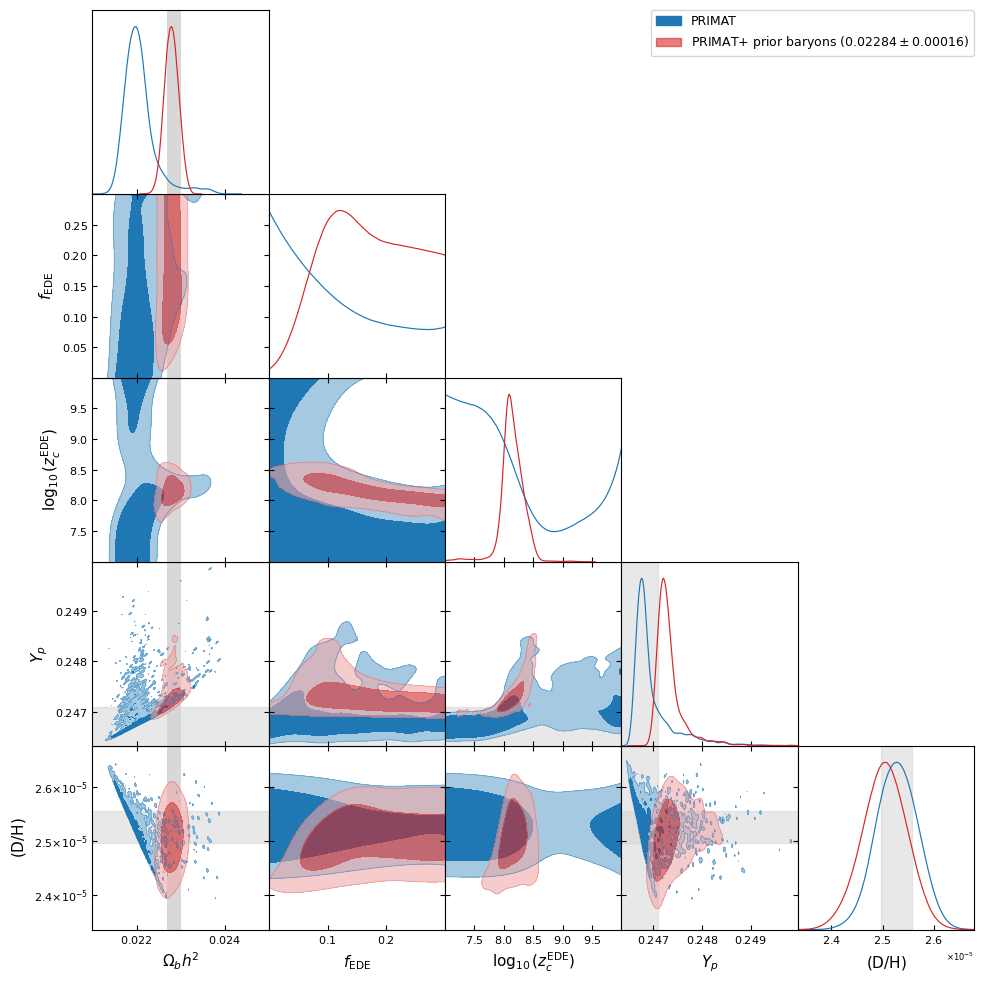

In [4]:
# Create GetDist plotter
g = plots.get_subplot_plotter()

# Configure plot settings
g.settings.num_plot_contours = 2  # Show 68% and 95% contours
g.settings.alpha_filled_add = 0.6  # Transparency of filled contours
g.settings.linewidth = 1.5

# Create triangle plot with all sampled parameters
# This shows 1D posteriors on the diagonal and 2D contours off-diagonal

g.triangle_plot([samples1,samples2],
                ['omegabh2', 'fEDE', 'log10zcEDE','YHe','DH'],
                filled=True,
                #plot_3d_with_param='sigma1_B', 
                legend_labels=['PRIMAT',r'PRIMAT+ prior baryons ($0.02284 \pm 0.00016$)'],
                legend_loc='upper right',
                contour_colors=['tab:blue','tab:red']
                )

# Add vertical bar for omegabh2 (Planck 2018 value) in all triangle subplots where omegabh2 is on x or y axis
import matplotlib.patches as patches
omegabh2_central = 0.02285
omegabh2_width = 2*0.00016
YHe_central = 0.2458
YHe_width = 2*0.0013
DH_central = 2.527e-5
DH_width = 2*0.030e-5
axes = g.subplots
if axes is not None:
    n = axes.shape[0]
    param_names = ['omegabh2', 'fEDE', 'log10zcEDE','YHe','DH']
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            # Only fill if this subplot exists (lower triangle and diagonal)
            if ax is not None and (i >= j):
                # Restrict omegabh2 range on x-axis (j==0)
                if j == 0:
                    ax.set_xlim(0.021, 0.025)
                    rect = patches.Rectangle((omegabh2_central-omegabh2_width/2, ax.get_ylim()[0]), omegabh2_width, ax.get_ylim()[1]-ax.get_ylim()[0],
                                         linewidth=0, edgecolor=None, facecolor='gray', alpha=0.3, zorder=0)
                    ax.add_patch(rect)
                # Restrict omegabh2 range on y-axis (i==0) and not the same as above (i!=j)
                if i == 0 and j != 0:
                    ax.set_ylim(0.021, 0.025)
                    rect = patches.Rectangle((ax.get_xlim()[0], omegabh2_central-omegabh2_width/2), ax.get_xlim()[1]-ax.get_xlim()[0], omegabh2_width,
                                         linewidth=0, edgecolor=None, facecolor='gray', alpha=0.3, zorder=0)
                    ax.add_patch(rect)
                # Always add both bands in YHe-DH and DH-YHe panels
                if (param_names[i], param_names[j]) == ('YHe', 'DH') or (param_names[i], param_names[j]) == ('DH', 'YHe'):
                    ax.axvspan(YHe_central-YHe_width/2, YHe_central+YHe_width/2, color='lightgray', alpha=0.5, zorder=0)
                    ax.axhspan(DH_central-DH_width/2, DH_central+DH_width/2, color='lightgray', alpha=0.5, zorder=0)
                # Add band for YHe constraint (vertical for 1D, horizontal for 2D)
                elif param_names[i] == 'YHe':
                    if i == j:  # 1D marginal (diagonal)
                        ax.axvspan(YHe_central-YHe_width/2, YHe_central+YHe_width/2, color='lightgray', alpha=0.5, zorder=0)
                    else:  # 2D plot, YHe is y-axis
                        ax.axhspan(YHe_central-YHe_width/2, YHe_central+YHe_width/2, color='lightgray', alpha=0.5, zorder=0)
                # Add band for DH constraint (vertical for 1D, horizontal for 2D)
                elif param_names[i] == 'DH':
                    if i == j:  # 1D marginal (diagonal)
                        ax.axvspan(DH_central-DH_width/2, DH_central+DH_width/2, color='lightgray', alpha=0.5, zorder=0)
                    else:  # 2D plot, DH is y-axis
                        ax.axhspan(DH_central-DH_width/2, DH_central+DH_width/2, color='lightgray', alpha=0.5, zorder=0)

# Display the plot
#plt.suptitle(f'Triangle Plot: {os.path.basename(chain_name1)}', fontsize=11, y=0.995)
plt.tight_layout()
plt.show()
g.export(output_dir + 'triangle_EDE' + postfix + '.pdf') 

## Additional Analysis Options

GetDist provides many other useful features for analyzing MCMC chains.

Parameter Statistics:
omegabh2            : 0.022071 ± 0.000383  [limits unavailable]
fEDE                : 0.115603 ± 0.086599  [limits unavailable]
log10zcEDE          : 8.120181 ± 0.889422  [limits unavailable]
YHe                 : 0.246978 ± 0.000446  [limits unavailable]
DH                  : 0.000025 ± 0.000000  [limits unavailable]
zcEDE               : 1125594703.956051 ± 2361925070.285582  [limits unavailable]
chi2                : -37.104949 ± 1.691419  [limits unavailable]
chi2__primat_likelihood.PrimatLikelihood: -37.104949 ± 1.691419  [limits unavailable]

Creating individual parameter plots...


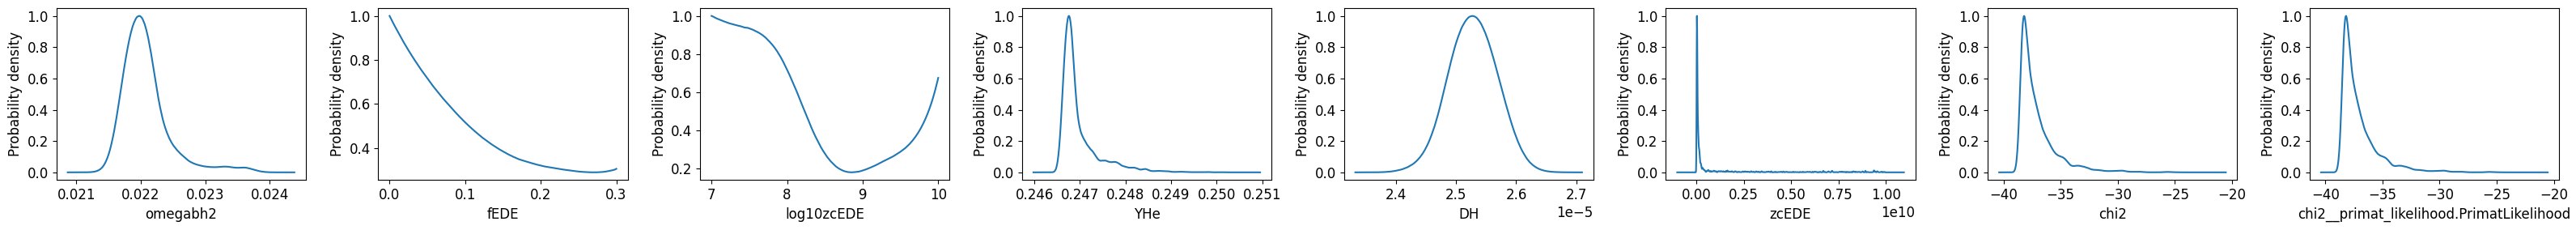

In [5]:
# Get parameter statistics (mean, std, confidence limits)
print("Parameter Statistics:")
print("=" * 60)
for param in samples1.getParamNames().list():
    mean = samples1.mean(param)
    std = samples1.std(param)
    limits = samples1.confidence(param, 0.68)  # 68% confidence interval
    if isinstance(limits, (list, tuple, np.ndarray)) and len(limits) == 2:
        print(f"{param:20s}: {mean:.6f} ± {std:.6f}  [{limits[0]:.6f}, {limits[1]:.6f}]")
    else:
        print(f"{param:20s}: {mean:.6f} ± {std:.6f}  [limits unavailable]")

# Plot individual 1D posteriors
print("\nCreating individual parameter plots...")
fig, axes = plt.subplots(1, len(samples1.getParamNames().list()), figsize=(4*len(samples1.getParamNames().list()), 3))
if len(samples1.getParamNames().list()) == 1:
    axes = [axes]
for i, param in enumerate(samples1.getParamNames().list()):
    try:
        density = samples1.get1DDensity(param)
        if hasattr(density, 'plot') and callable(density.plot):
            density.plot(axes[i])
        else:
            axes[i].plot(density.x, density.P, label=param)
        axes[i].set_xlabel(param)
        axes[i].set_ylabel('Probability density')
    except Exception as e:
        print(f"Could not plot {param}: {e}")
plt.tight_layout()
plt.show()